Loading CIFAR...
Dataset: (50000, 3072)
Train shape: (40000, 3072)
Validation shape: (5000, 3072)
Test shape: (5000, 3072)
Epoch 0 Train: 2.156487782060574 Val: 2.159605001307698 Test: 2.1544645273506537
Epoch 1 Train: 2.0153866180322293 Val: 2.0216322767592523 Test: 2.0205132374364996
Epoch 2 Train: 1.9445774055559708 Val: 1.9527419724309627 Test: 1.9533500427481678
Epoch 3 Train: 1.9040000180785657 Val: 1.9117621599519952 Test: 1.9156289133718296
Epoch 4 Train: 1.8759348825934863 Val: 1.8853800864528665 Test: 1.8920463019675298
Epoch 5 Train: 1.8384718883666014 Val: 1.8513192370520866 Test: 1.8527474205199665
Epoch 6 Train: 1.8196627585002498 Val: 1.8334351968647904 Test: 1.8362768927119524
Epoch 7 Train: 1.8017669951590265 Val: 1.8178046187673622 Test: 1.8177584783182579
Epoch 8 Train: 1.7847437446151226 Val: 1.8069770121747915 Test: 1.8036112396582222
Epoch 9 Train: 1.7668239797130159 Val: 1.7883812858793893 Test: 1.789899417569752
Epoch 10 Train: 1.750193598933383 Val: 1.772572403

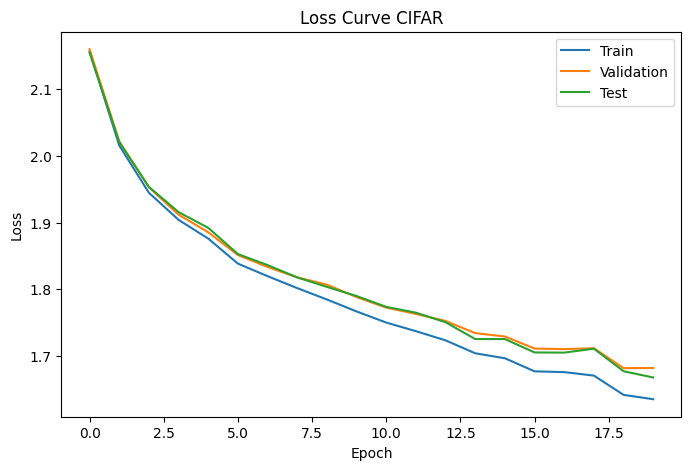

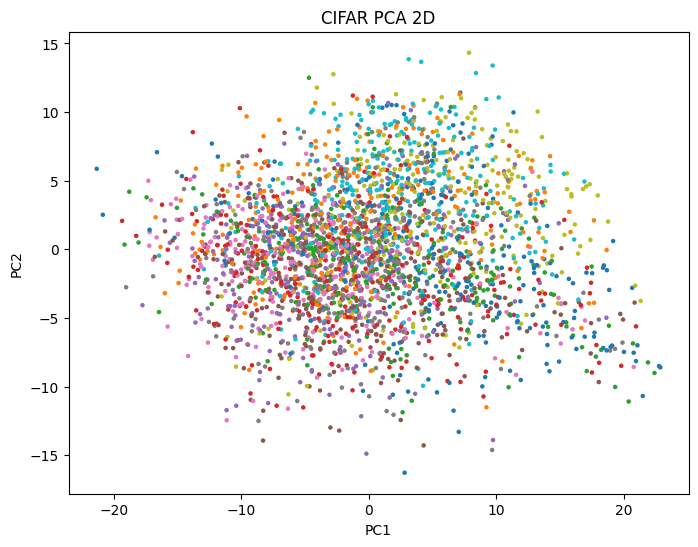

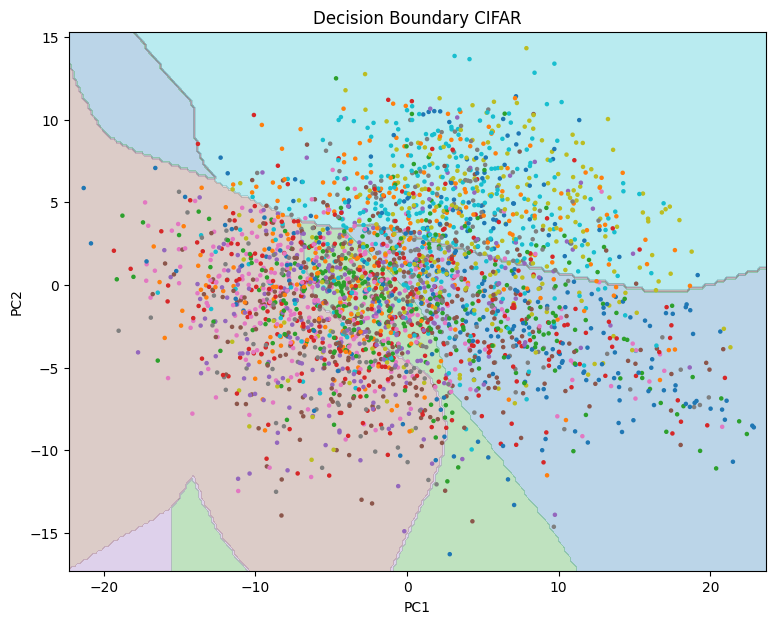

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# đặt seed để kết quả reproducible
np.random.seed(42)

# =====================================
# LOAD CIFAR TRAIN DATA
# =====================================

def load_cifar_train(folder, labels_csv):

    df = pd.read_csv(labels_csv)

    # map text label -> number
    label_map = {
        "airplane":0,
        "automobile":1,
        "bird":2,
        "cat":3,
        "deer":4,
        "dog":5,
        "frog":6,
        "horse":7,
        "ship":8,
        "truck":9
    }

    X = []
    y = []

    for i in range(len(df)):

        img_id = df.iloc[i,0]
        label = label_map[df.iloc[i,1]]

        path = os.path.join(folder,f"{img_id}.png")

        img = Image.open(path)
        img = np.array(img)

        # flatten 32x32x3 -> 3072
        X.append(img.flatten()/255.0)
        y.append(label)

    return np.array(X), np.array(y)


# =====================================
# LOAD CIFAR TEST DATA
# =====================================

def load_cifar_test(folder):

    files = sorted(os.listdir(folder))

    X = []

    for f in files:

        path = os.path.join(folder,f)

        img = Image.open(path)
        img = np.array(img)

        X.append(img.flatten()/255.0)

    return np.array(X)


# =====================================
# ONE HOT ENCODING
# =====================================

def one_hot(y,num_class=10):

    Y = np.zeros((len(y),num_class))
    Y[np.arange(len(y)),y] = 1

    return Y


# =====================================
# ACTIVATION FUNCTIONS
# =====================================

def sigmoid(z):
    return 1/(1+np.exp(-z))


def sigmoid_derivative(a):
    return a*(1-a)


def softmax(z):

    # numerical stability
    z = z - np.max(z,axis=1,keepdims=True)

    exp = np.exp(z)

    return exp/np.sum(exp,axis=1,keepdims=True)


# =====================================
# NEURAL NETWORK
# =====================================

class NeuralNetwork:

    def __init__(self):

        # input = 3072 (32x32x3)
        self.W1 = np.random.randn(3072,128)*0.01
        self.b1 = np.zeros((1,128))

        self.W2 = np.random.randn(128,10)*0.01
        self.b2 = np.zeros((1,10))


    def forward(self,X):

        self.Z1 = X @ self.W1 + self.b1
        self.A1 = sigmoid(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2


    def loss(self,Y,A):

        return -np.mean(np.sum(Y*np.log(A+1e-8),axis=1))


    def backward(self,X,Y):

        m = X.shape[0]

        dZ2 = (self.A2-Y)/m

        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2,axis=0,keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_derivative(self.A1)

        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1,axis=0,keepdims=True)

        return dW1,db1,dW2,db2


    def update(self,dW1,db1,dW2,db2,lr):

        self.W1 -= lr*dW1
        self.b1 -= lr*db1

        self.W2 -= lr*dW2
        self.b2 -= lr*db2


# =====================================
# ACCURACY
# =====================================

def accuracy(pred,y):

    p = np.argmax(pred,axis=1)

    return np.mean(p==y)


# =====================================
# PCA DIMENSION REDUCTION
# =====================================

class PCA:

    def __init__(self,k=2):
        self.k = k

    def fit(self,X):

        self.mean = np.mean(X,axis=0)

        Xc = X-self.mean

        U,S,Vt = np.linalg.svd(Xc,full_matrices=False)

        self.W = Vt[:self.k]

        return self


    def transform(self,X):

        Xc = X-self.mean

        return Xc @ self.W.T


    def inverse_transform(self,Z):

        return Z @ self.W + self.mean


# =====================================
# LOAD DATASET
# =====================================

print("Loading CIFAR...")

X,y = load_cifar_train(
    "data/train/train",
    "data/trainLabels.csv"
)

print("Dataset:",X.shape)



# =====================================
# TRAIN / VAL / TEST SPLIT
# =====================================

train_size = 40000
val_size = 5000

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

Y_train = one_hot(y_train)
Y_val = one_hot(y_val)
Y_test = one_hot(y_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
# =====================================
# TRAIN MODEL
# =====================================

model = NeuralNetwork()

epochs = 20
lr = 0.05
batch_size = 128

train_loss=[]
val_loss=[]
test_loss=[]

n = X_train.shape[0]

for e in range(epochs):

    perm = np.random.permutation(n)

    X_train = X_train[perm]
    Y_train = Y_train[perm]
    y_train = y_train[perm]

    for i in range(0,n,batch_size):

        X_batch = X_train[i:i+batch_size]
        Y_batch = Y_train[i:i+batch_size]

        A = model.forward(X_batch)

        dW1,db1,dW2,db2 = model.backward(X_batch,Y_batch)

        model.update(dW1,db1,dW2,db2,lr)

    train_pred = model.forward(X_train)
    val_pred = model.forward(X_val)
    test_pred = model.forward(X_test)

    train_loss.append(model.loss(Y_train,train_pred))
    val_loss.append(model.loss(Y_val,val_pred))
    test_loss.append(model.loss(Y_test,test_pred))

    print(
        "Epoch",e,
        "Train:",train_loss[-1],
        "Val:",val_loss[-1],
        "Test:",test_loss[-1]
    )


# =====================================
# LOSS CURVE
# =====================================

plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Train")
plt.plot(val_loss,label="Validation")
plt.plot(test_loss,label="Test")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curve CIFAR")

plt.legend()

plt.show()


# =====================================
# PCA VISUALIZATION
# =====================================

plot_n = 3000

idx = np.random.choice(X_train.shape[0],plot_n,replace=False)

X_plot = X_train[idx]
y_plot = y_train[idx]

pca = PCA(2).fit(X_plot)

Z = pca.transform(X_plot)

plt.figure(figsize=(8,6))

plt.scatter(Z[:,0],Z[:,1],c=y_plot,cmap="tab10",s=5)

plt.title("CIFAR PCA 2D")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


# =====================================
# DECISION BOUNDARY
# =====================================

x_min,x_max = Z[:,0].min()-1 , Z[:,0].max()+1
y_min,y_max = Z[:,1].min()-1 , Z[:,1].max()+1

h = 0.2

xx,yy = np.meshgrid(
    np.arange(x_min,x_max,h),
    np.arange(y_min,y_max,h)
)

grid_2d = np.c_[xx.ravel(),yy.ravel()]

X_grid = pca.inverse_transform(grid_2d)

X_grid = np.clip(X_grid,0,1)

pred = model.forward(X_grid)

grid_pred = np.argmax(pred,axis=1)

grid_pred = grid_pred.reshape(xx.shape)

plt.figure(figsize=(9,7))

plt.contourf(xx,yy,grid_pred,cmap="tab10",alpha=0.3)

plt.scatter(Z[:,0],Z[:,1],c=y_plot,cmap="tab10",s=5)

plt.title("Decision Boundary CIFAR")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## Sau khi giảm chiều dữ liệu từ 3072 xuống 2 chiều bằng PCA, các lớp dữ liệu chồng lấn đáng kể nên ranh giới phân lớp không rõ ràng. Tuy nhiên mô hình vẫn học được các vùng quyết định trong không gian PCA.